In [2]:
# ============================================================
# Imports
# ============================================================

import sys
sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt

from src.data_loader import KITTILoader

from src.proxies.gps_proxy import extract_all_gps_proxies
from src.proxies.imu_proxy import extract_all_imu_proxies
from src.proxies.camera_proxy import extract_all_camera_proxies
from src.proxies.lidar_proxy import extract_all_lidar_proxies

from src.features.normalization import MotionNormalizer

from src.features.f1_kinematic import (
    extract_all_f1_features
)

from src.features.f2_scene import (
    compute_f2
)

from src.features.gmis import (
    compute_gmis
)

print("Imports successful.")

Imports successful.


In [3]:
datasets = KITTILoader.load_multiple_drives()

print("\nLoaded Drives:")
print(list(datasets.keys()))

Loading drive 0009...
Loading drive 0015...
Loading drive 0051...
Loading drive 0091...

Loaded 4 drives.

Loaded Drives:
['0009', '0015', '0051', '0091']


In [4]:
results = {}

for drive, loader in datasets.items():

    print(f"\n{'='*60}")
    print(f"Processing Drive {drive}")
    print(f"{'='*60}")

    data = loader.raw_data

    dt = loader.get_dt()

    # --------------------------------------------------------
    # GPS
    # --------------------------------------------------------

    gps = extract_all_gps_proxies(
        data.oxts,
        dt=dt
    )

    # --------------------------------------------------------
    # IMU
    # --------------------------------------------------------

    imu = extract_all_imu_proxies(
        data.oxts,
        dt=dt
    )

    # --------------------------------------------------------
    # Camera
    # --------------------------------------------------------

    camera_frames = [
        np.array(data.get_cam2(i))
        for i in range(min(
            len(data.cam2_files),
            200
        ))
    ]

    cam = extract_all_camera_proxies(
        camera_frames
    )

    # --------------------------------------------------------
    # LiDAR
    # --------------------------------------------------------

    lidar_scans = [
        data.get_velo(i)
        for i in range(min(
            len(data.velo_files),
            200
        ))
    ]

    lidar_oxts = data.oxts[:len(lidar_scans)]

    lidar = extract_all_lidar_proxies(
        lidar_scans,
        lidar_oxts
    )

    # --------------------------------------------------------
    # ALIGN LENGTHS
    # --------------------------------------------------------

    min_len = min(
        len(gps["delta_v"]),
        len(gps["heading_rate"]),
        len(imu["delta_v"]),
        len(imu["yaw_rate"]),
        len(cam["flow_magnitude"]),
        len(lidar["icp_residual"])
    )

    gps_trim = {
        k: v[:min_len]
        for k, v in gps.items()
    }

    imu_trim = {
        k: v[:min_len]
        for k, v in imu.items()
    }

    cam_trim = {
        "flow_magnitude":
            cam["flow_magnitude"][:min_len]
    }

    lidar_trim = {
        "icp_residual":
            lidar["icp_residual"][:min_len]
    }

    # --------------------------------------------------------
    # NORMALIZATION
    # --------------------------------------------------------

    normalizer = MotionNormalizer()

    normalizer.fit(
        gps_trim,
        imu_trim,
        cam_trim,
        lidar_trim
    )

    z = normalizer.transform(
        gps_trim,
        imu_trim,
        cam_trim,
        lidar_trim
    )

    # --------------------------------------------------------
    # F1
    # --------------------------------------------------------

    f1_result = extract_all_f1_features(
        z=z,
        gps_speed=gps_trim["speed"]
    )

    f1 = f1_result["f1"]

    # --------------------------------------------------------
    # F2
    # --------------------------------------------------------

    f2 = compute_f2(
        z["gps_delta_v"],
        z["lidar_icp"]
    )

    # --------------------------------------------------------
    # GMIS
    # --------------------------------------------------------

    gmis = compute_gmis(
        z["gps_delta_v"],
        z["imu_delta_v"],
        z["lidar_icp"],
        z["camera_flow"]
    )

    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    results[drive] = {

        "f1": f1,

        "f2": f2,

        "gmis": gmis,

        "gps": gps_trim,

        "imu": imu_trim,

        "cam": cam_trim,

        "lidar": lidar_trim
    }

    print(
        f"Drive {drive} complete "
        f"(frames={min_len})"
    )


Processing Drive 0009
Processing scan 20/200
Processing scan 40/200
Processing scan 60/200
Processing scan 80/200
Processing scan 100/200
Processing scan 120/200
Processing scan 140/200
Processing scan 160/200
Processing scan 180/200
Normalization parameters fitted:
  gps_delta_v         : μ= -0.2409, σ=  0.3571
  gps_heading_rate    : μ= -0.0016, σ=  0.0657
  imu_delta_v         : μ= -0.2948, σ=  0.3605
  imu_yaw_rate        : μ=  0.0053, σ=  0.0315
  camera_flow         : μ= 14.4882, σ=  3.8495
  lidar_icp           : μ=  0.2150, σ=  0.0280
Drive 0009 complete (frames=199)

Processing Drive 0015
Processing scan 20/200
Processing scan 40/200
Processing scan 60/200
Processing scan 80/200
Processing scan 100/200
Processing scan 120/200
Processing scan 140/200
Processing scan 160/200
Processing scan 180/200
Normalization parameters fitted:
  gps_delta_v         : μ= -0.1587, σ=  0.4415
  gps_heading_rate    : μ= -0.0070, σ=  0.0140
  imu_delta_v         : μ= -0.2165, σ=  0.4625
  imu_ya

In [5]:
for drive, r in results.items():

    print(f"\n{'='*60}")
    print(f"DRIVE {drive}")
    print(f"{'='*60}")

    print(
        f"F1 Mean   : "
        f"{np.nanmean(r['f1']):.4f}"
    )

    print(
        f"F2 Mean   : "
        f"{np.nanmean(r['f2']):.4f}"
    )

    print(
        f"GMIS Mean : "
        f"{np.nanmean(r['gmis']):.4f}"
    )


DRIVE 0009
F1 Mean   : 0.8774
F2 Mean   : 0.7302
GMIS Mean : 0.7066

DRIVE 0015
F1 Mean   : 1.2961
F2 Mean   : 0.9191
GMIS Mean : 0.8720

DRIVE 0051
F1 Mean   : 1.5113
F2 Mean   : 0.8376
GMIS Mean : 0.8100

DRIVE 0091
F1 Mean   : 1.3426
F2 Mean   : 0.8590
GMIS Mean : 0.9310


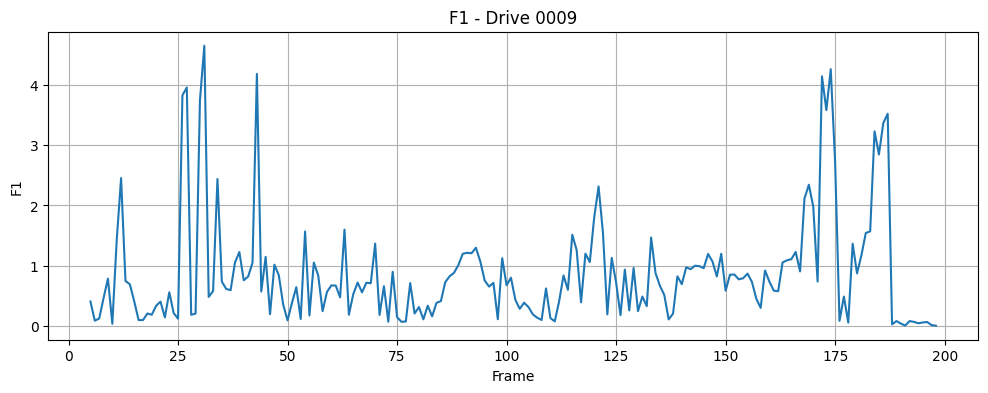

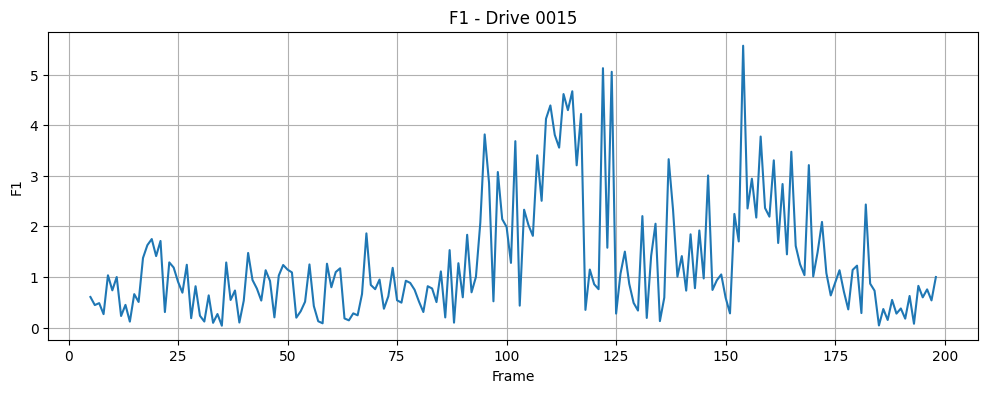

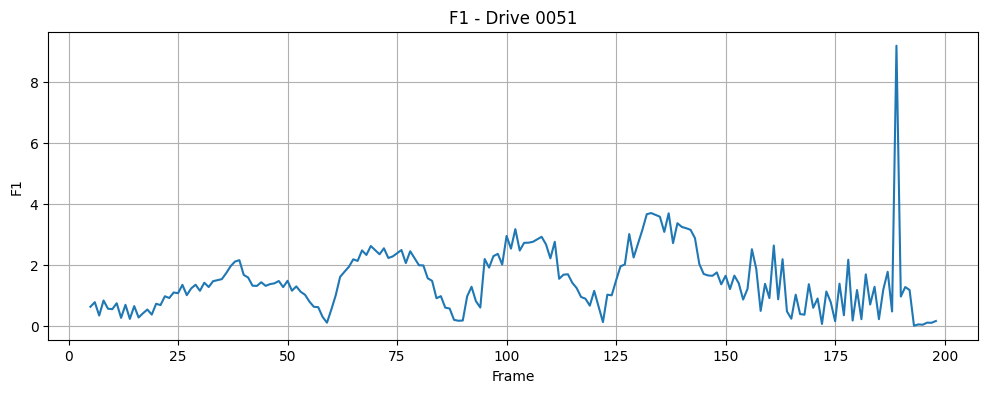

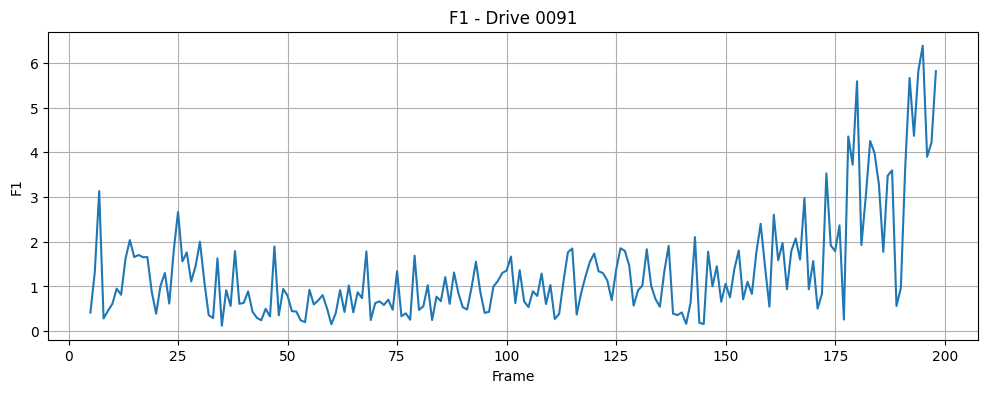

In [6]:
for drive, r in results.items():

    plt.figure(figsize=(12,4))

    plt.plot(
        r["f1"]
    )

    plt.title(
        f"F1 - Drive {drive}"
    )

    plt.xlabel("Frame")

    plt.ylabel("F1")

    plt.grid(True)

    plt.show()

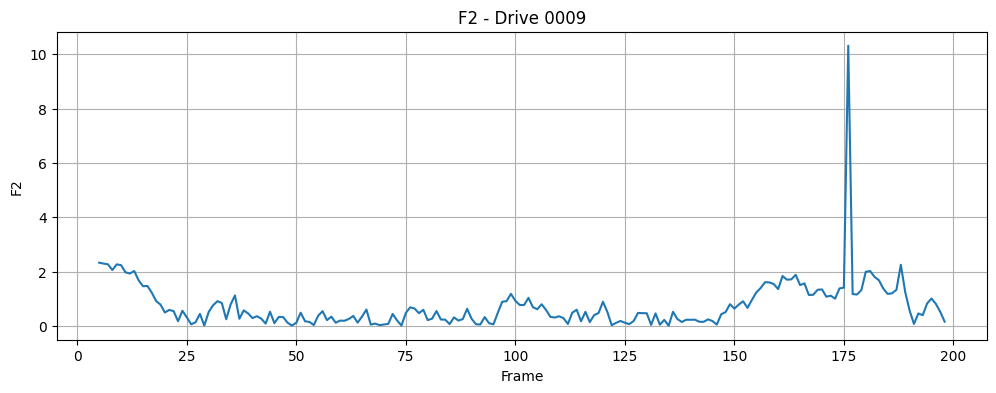

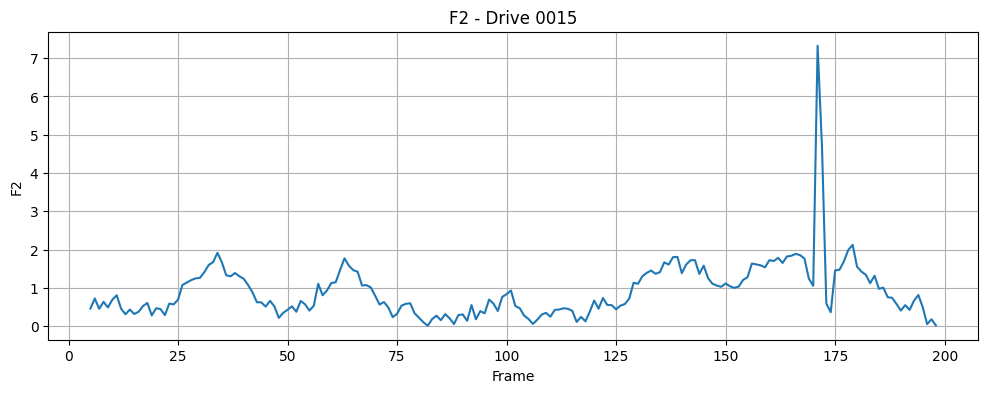

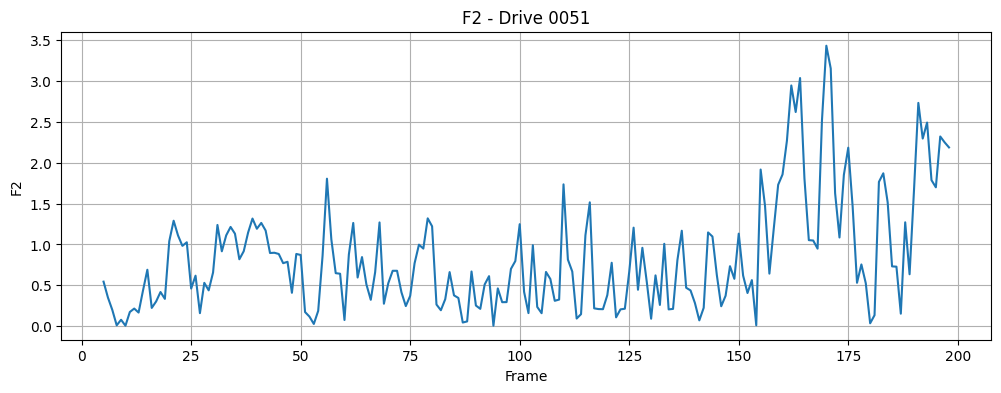

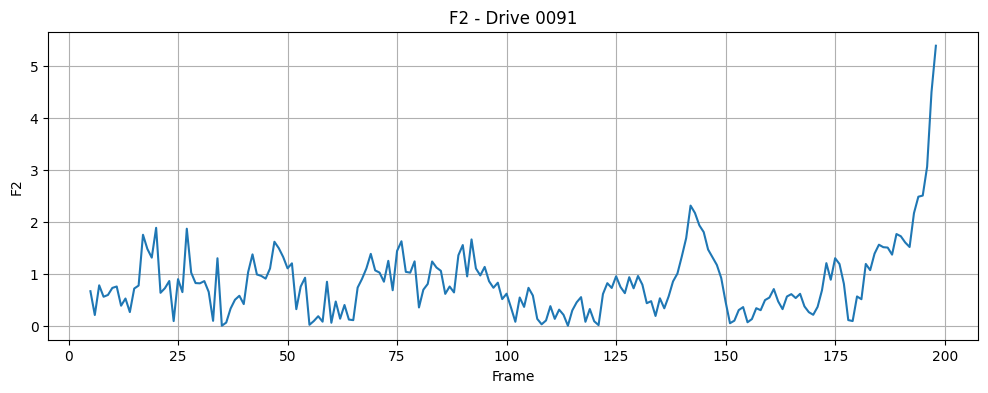

In [7]:
for drive, r in results.items():

    plt.figure(figsize=(12,4))

    plt.plot(
        r["f2"]
    )

    plt.title(
        f"F2 - Drive {drive}"
    )

    plt.xlabel("Frame")

    plt.ylabel("F2")

    plt.grid(True)

    plt.show()

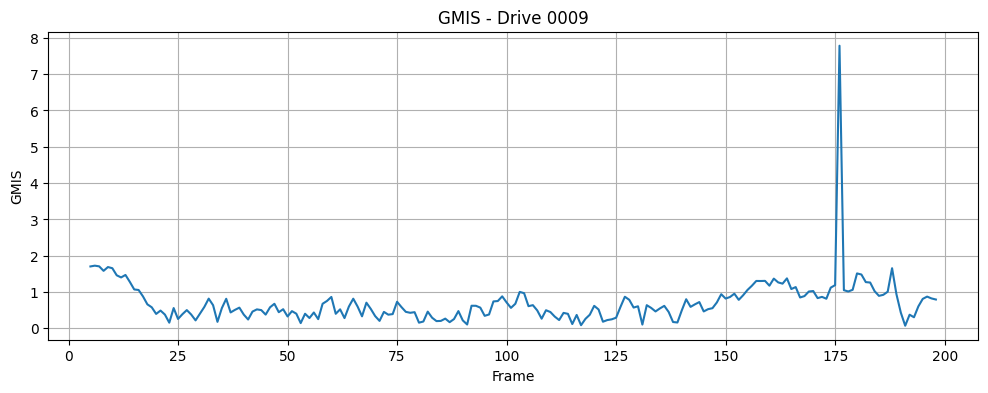

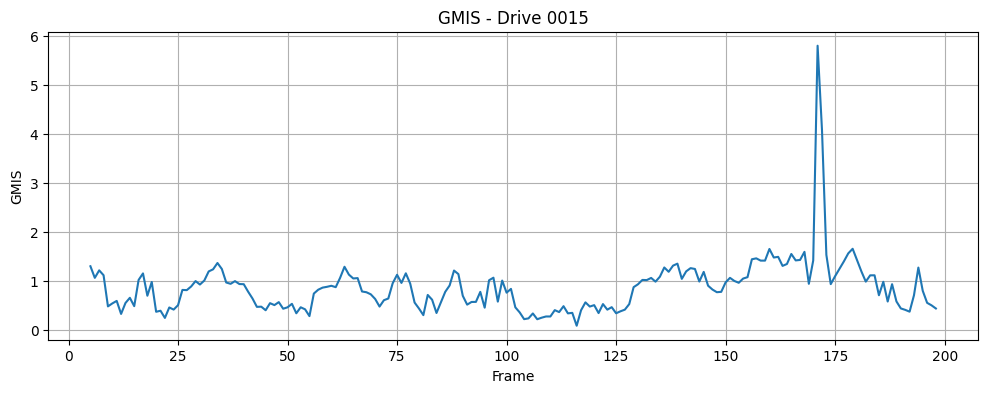

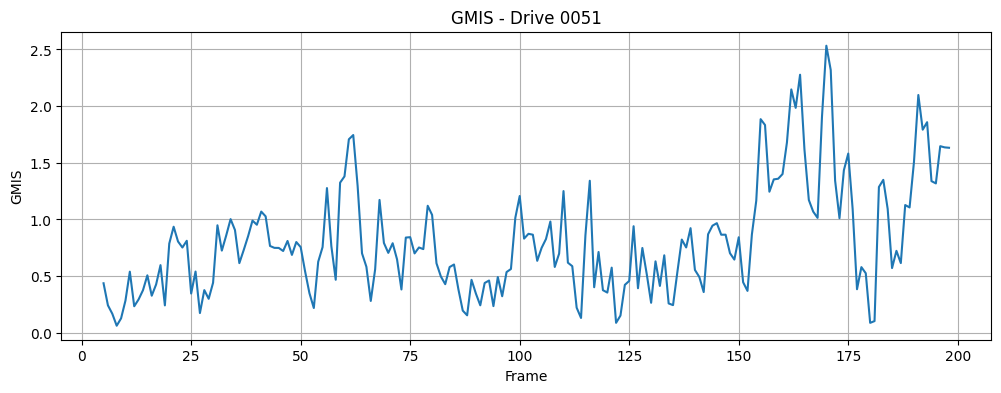

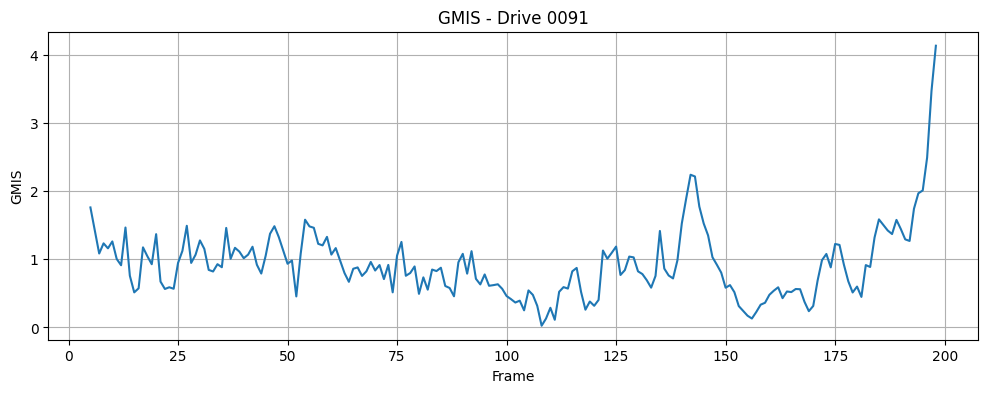

In [8]:
for drive, r in results.items():

    plt.figure(figsize=(12,4))

    plt.plot(
        r["gmis"]
    )

    plt.title(
        f"GMIS - Drive {drive}"
    )

    plt.xlabel("Frame")

    plt.ylabel("GMIS")

    plt.grid(True)

    plt.show()

In [9]:
print("\n=== FEATURE VALIDATION ===")

for drive, r in results.items():

    print(f"\nDrive {drive}")

    print(
        "F1 valid:",
        np.isfinite(
            np.nanmean(r["f1"])
        )
    )

    print(
        "F2 valid:",
        np.isfinite(
            np.nanmean(r["f2"])
        )
    )

    print(
        "GMIS valid:",
        np.isfinite(
            np.nanmean(r["gmis"])
        )
    )


=== FEATURE VALIDATION ===

Drive 0009
F1 valid: True
F2 valid: True
GMIS valid: True

Drive 0015
F1 valid: True
F2 valid: True
GMIS valid: True

Drive 0051
F1 valid: True
F2 valid: True
GMIS valid: True

Drive 0091
F1 valid: True
F2 valid: True
GMIS valid: True


In [10]:
np.nanmean(f1)
np.nanmean(f2)
np.nanmean(gmis)

np.float64(0.9309671429170358)

In [11]:
np.nanmax(f1)
np.nanmax(f2)
np.nanmax(gmis)

np.float64(4.13577494105802)